In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
path = '/Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project'

In [3]:
df_pushed_year = pd.read_csv(f'{path}/Modeling/common_NPI_pushed_year_df_with_pca_1_scaled_type_tot_risk_covid_3.csv').drop('Unnamed: 0',axis=1)
df_origin = pd.read_csv(f'{path}/Modeling/original_year_with_type_risk_tot_risk_pca_covid_3.csv').drop('Unnamed: 0', axis=1)

In [4]:
df_train = df_pushed_year[df_pushed_year['year']<=2020].copy()
df_val = df_origin[df_origin['year']==2020].copy() # use 2020 data predict for 2021, the df_val_df dataset is in original year
df_val['year']=2021
df_val['Is_Covid']=1
actual_total_y = sum(df_origin[df_origin['year']==2021]['Tot_Mdcr_Pymt_Amt'])
actual_y = df_origin[df_origin['year']==2021]['Tot_Mdcr_Pymt_Amt']
actual_total_y

109259516579.438

In [5]:
df_2021 = df_origin[df_origin['year']==2021].copy()
actual_total_2022 = sum(df_origin[df_origin['year']==2022]['Tot_Mdcr_Pymt_Amt'])
df_2021['year'] = 2022
df_2021['Is_Covid'] = 0
df_2022 = df_origin[df_origin['year']==2022].copy()
df_2022['year'] = 2023
actual_total_2023 = sum(df_origin[df_origin['year']==2023]['Tot_Mdcr_Pymt_Amt'])

# Preprocessing Columns

In [7]:
label_cols = ['APP_Tot_Risk','PrimaryCare_Tot_Risk','MedicalSpecialtyOther_Tot_Risk','LabPathology_Tot_Risk','PharmacyNutrition_Tot_Risk']

def label_num_to_cat(df,cols):
    for c in cols:
        df[c] = df[c].astype(int).astype('object')
    return

In [8]:
label_num_to_cat(df_train,label_cols)
label_num_to_cat(df_val,label_cols)
label_num_to_cat(df_2021,label_cols)
label_num_to_cat(df_2022,label_cols)

In [16]:
from sklearn.preprocessing import OneHotEncoder

def enc_df(df):
    num_cols = df.select_dtypes(include='number').columns.tolist()
    num_cols = [c for c in num_cols if c not in ['Rndrng_NPI', 'Tot_HCPCS_Cds', 'Tot_Srvcs','Tot_Mdcr_Pymt_Amt','pca_1_scaled']]
    cat_cols = df.select_dtypes(exclude='number').columns.tolist()
    cat_cols = [c for c in cat_cols if c!='Rndrng_Prvdr_State_Abrvtn']

    cat_orders = []

    for c in cat_cols:
        cat_orders.append(df[c].unique().tolist())

    enc = OneHotEncoder(
        categories=cat_orders,
        handle_unknown='ignore',
        sparse_output=False,
        feature_name_combiner=lambda feature,category: f'{feature.split('_')[-1]}_{category}' if 'Rndrng' in feature else f'{feature}_{category}'
    )

    X_cat = enc.fit_transform(df[cat_cols])

    dummy_names = enc.get_feature_names_out(cat_cols)

    X_cat_df = pd.DataFrame(X_cat,columns=dummy_names,index=df.index)
    X_train = pd.concat([df[num_cols+['Tot_Mdcr_Pymt_Amt']],X_cat_df],axis=1)
    return X_train


In [17]:
X_train = enc_df(df_train)
X_val = enc_df(df_val)

In [18]:
X_train['Tot_Mdcr_Pymt_Amt'] = X_train['Tot_Mdcr_Pymt_Amt'].apply(lambda x:x if x!=0 else 1)
X_train['Tot_Benes'] = X_train['Tot_Benes'].apply(lambda x:x if x!=0 else 1)
X_val['Tot_Benes'] = X_val['Tot_Benes'].apply(lambda x:x if x!=0 else 1)

In [19]:
df_2021 = enc_df(df_2021)
df_2022 = enc_df(df_2022)

In [20]:
RESULT_DF = pd.DataFrame(columns=['formula','val_percentage','train_percentage','AIC','BIC','val_deviance','pseudo_R^2','abs_val_percentage'])
RESULT_DF

,formula,val_percentage,train_percentage,AIC,BIC,val_deviance,pseudo_R^2,abs_val_percentage


In [21]:
X_train.columns

Index(['Tot_Benes', 'Bene_Avg_Age', 'Bene_Avg_Risk_Scre', 'Tot_Risk', 'year',
       'Is_Covid', 'Tot_Mdcr_Pymt_Amt', 'Cd_I', 'Cd_O', 'Type_PrimaryCare',
       'Type_LabPathology', 'Type_Anesthesia', 'Type_OBGYN',
       'Type_SurgeryOther', 'Type_CardioVascularSurgery', 'Type_APP',
       'Type_Cardiology', 'Type_MedicalSpecialtyOther', 'Type_RehabTherapy',
       'Type_FacilitySupplierProgram', 'Type_OncologyHeme',
       'Type_RadiologyImaging', 'Type_AcuteCare', 'Type_BehavioralHealth',
       'Type_VisionHearing', 'Type_PharmacyNutrition', 'Type_UnknownOther',
       'Ind_Y', 'Ind_N', 'APP_Tot_Risk_2', 'APP_Tot_Risk_1', 'APP_Tot_Risk_0',
       'PrimaryCare_Tot_Risk_0', 'PrimaryCare_Tot_Risk_2',
       'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_2',
       'MedicalSpecialtyOther_Tot_Risk_0', 'MedicalSpecialtyOther_Tot_Risk_1',
       'LabPathology_Tot_Risk_3', 'LabPathology_Tot_Risk_2',
       'LabPathology_Tot_Risk_0', 'LabPathology_Tot_Risk_1',
       'PharmacyNut

In [22]:
feature_cols = [c for c in X_train.columns.tolist() if c not in ['Tot_Benes','Tot_Risk','Tot_Mdcr_Pymt_Amt']]

# Null Model

In [23]:
MODEL_null_offset = smf.glm(
    formula="Tot_Mdcr_Pymt_Amt ~ 1",
    data=df_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    offset=np.log(df_train["Tot_Benes"]),
).fit()

In [34]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_5.csv')

In [111]:
RESULT_DF = pd.read_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_5.csv').drop('Unnamed: 0',axis=1)
RESULT_DF.sort_values('val_deviance').iat[1,0]

"['Type_OncologyHeme', 'Type_RehabTherapy', 'Type_BehavioralHealth', 'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_0']"

# Auto selection

In [134]:
def next_best_formula(result_df,col):
    features = "".join(result_df.sort_values(col).iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(",")
    formula = 'Tot_Mdcr_Pymt_Amt ~ '
    for x in features:
        formula+=f'{x}+'
    return formula[:-1]

def feature_selection(result_df,col,feature_cols):
    FORMULA = next_best_formula(result_df,col)
    for c in feature_cols:
        if c not in FORMULA:
            if feature_cols[i]=='year':
                formula = FORMULA + '+cr(year,df=3)'
            else:
                formula = FORMULA + f'+{c}'
            MODEL = smf.glm(
                formula = formula,
                data = X_train,
                family = sm.families.Gamma(link=sm.families.links.Log()),
                offset = np.log(X_train['Tot_Benes'])
            ).fit()

            y_pred = MODEL.predict(X_val,offset=np.log(X_val['Tot_Benes']))

            val_p = sum(y_pred)/actual_total_y

            train_p = sum(MODEL.predict(X_train,offset=np.log(X_train['Tot_Benes'])))/sum(X_train['Tot_Mdcr_Pymt_Amt'])

            r2_dev = 1 - MODEL.deviance / MODEL_null_offset.deviance

            val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

            temp = pd.DataFrame({
                'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
                'val_percentage': [val_p],
                'train_percentage': [train_p],
                'AIC':[MODEL.aic],
                'BIC':[MODEL.bic_llf],
                'val_deviance': [val_d],
                'pseudo_R^2': [r2_dev],
                'abs_val_percentage':[abs(val_p-1)]
            })
            result_df = pd.concat([result_df,temp],axis=0)
    
    return result_df

In [117]:
RESULT_DF=pd.read_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_5.csv').drop('Unnamed: 0',axis=1)
RESULT_DF.sort_values('val_deviance').iat[0,0]

"['Type_OncologyHeme', 'Type_RehabTherapy', 'Type_BehavioralHealth', 'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_0', 'Type_SurgeryOther']"

In [152]:
def best_formula(result_df,col):
    features = "".join(result_df.sort_values(col).iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(",")
    print(features)
    print(len(features))
    formula = 'Tot_Mdcr_Pymt_Amt ~ '
    for x in features:
        formula+=f'{x}+'
    return formula[:-1]

In [162]:
df = feature_selection(RESULT_DF,'val_deviance',feature_cols)
df.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_5.csv')
df.sort_values('val_deviance')

,formula,val_percentage,train_percentage,AIC,BIC,val_deviance,pseudo_R^2,abs_val_percentage
0,"[Type_OncologyHeme, Type_RehabTherapy, Type_Be...",0.929290,1.193158,2.052559e+08,2.052561e+08,10790.558167,0.165741,0.070710
0,"[Type_OncologyHeme, Type_RehabTherapy, Type_Be...",0.979466,1.192818,2.052120e+08,2.052122e+08,10924.158419,0.165404,0.020534
0,"[Type_OncologyHeme, Type_RehabTherapy, Type_Be...",0.979629,1.192939,2.052034e+08,2.052036e+08,10929.466094,0.165501,0.020371
0,"[Type_OncologyHeme, Type_RehabTherapy, Type_Be...",0.979629,1.192939,2.052034e+08,2.052036e+08,10929.466095,0.165501,0.020371
0,"[Type_OncologyHeme, Type_RehabTherapy, Type_Be...",0.979436,1.192692,2.052067e+08,2.052069e+08,10930.070587,0.165340,0.020564
...,...,...,...,...,...,...,...,...
102,"['Type_OncologyHeme', 'Type_RehabTherapy', 'Cd...",1.127771,0.003538,1.849755e+08,-1.007767e+08,65358.082532,0.106664,0.127771
53,"['Type_OncologyHeme', 'Cd_I']",1.173855,0.003538,1.847312e+08,-1.005158e+08,70212.764155,0.075824,0.173855
54,"['Type_OncologyHeme', 'Cd_O']",1.173855,0.003538,1.847312e+08,-1.005158e+08,70212.764156,0.075824,0.173855
4,['Cd_I'],1.177151,0.003538,1.853483e+08,-1.000432e+08,71199.051853,0.019967,0.177151


In [163]:
RESULT_DF=pd.read_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_5.csv').drop('Unnamed: 0',axis=1)
print(len("".join(RESULT_DF.sort_values('val_deviance').iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(",")))
RESULT_DF.sort_values('val_deviance').iat[0,0]

12


"['Type_OncologyHeme', 'Type_RehabTherapy', 'Type_BehavioralHealth', 'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_0', 'Type_SurgeryOther', 'APP_Tot_Risk_0', 'Type_CardioVascularSurgery', 'Type_VisionHearing', 'Type_Cardiology', 'MedicalSpecialtyOther_Tot_Risk_2', 'Is_Covid']"

['Type_OncologyHeme', 'Type_RehabTherapy', 'Type_BehavioralHealth', 'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_0', 'Type_SurgeryOther', 'APP_Tot_Risk_0', 'Type_CardioVascularSurgery', 'Type_VisionHearing', 'Type_Cardiology', 'MedicalSpecialtyOther_Tot_Risk_2', 'Is_Covid']
12
0.9292901395074106


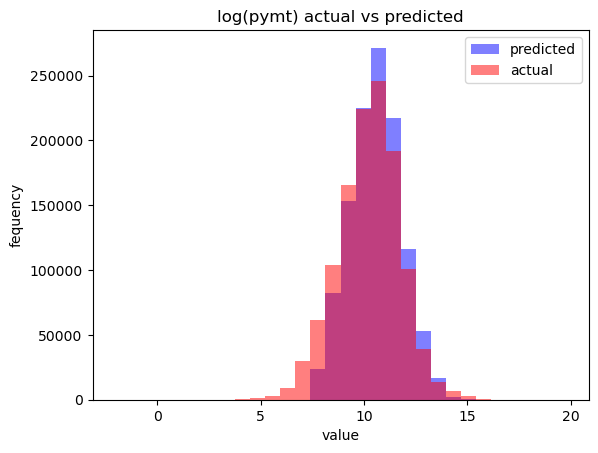

                 Generalized Linear Model Regression Results                  
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880931
Model Family:                   Gamma   Df Model:                           12
Link Function:                    Log   Scale:                          87.914
Method:                          IRLS   Log-Likelihood:            -1.0263e+08
Date:                Mon, 09 Mar 2026   Deviance:                   7.0588e+06
Time:                        12:57:38   Pearson chi2:                 6.05e+08
No. Iterations:                    10   Pseudo R-squ. (CS):           0.002311
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [ ]:
formula = best_formula(RESULT_DF,'val_deviance')

MODEL_1 = smf.glm(
                formula = formula,
                data = X_train,
                family = sm.families.Gamma(link=sm.families.links.Log()),
                offset = np.log(X_train['Tot_Benes'])
            ).fit()

y_pred = MODEL_1.predict(X_val,offset=np.log(X_val['Tot_Benes'].apply(lambda x:x if x!=0 else 1)))

print(sum(y_pred)/actual_total_y)

log_y_pred = np.log(y_pred.apply(lambda x:x if x!=0 else 1))
log_actual_y = np.log(actual_y.apply(lambda x:x if x!=0 else 1))

bins = np.histogram_bin_edges(np.concatenate([log_y_pred, log_actual_y]), bins=30)

plt.hist(log_y_pred, bins=bins, alpha=0.5, color="blue", label="predicted")
plt.hist(log_actual_y, bins=bins, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted')
plt.show()

print(MODEL_1.summary())

['Type_OncologyHeme', 'Type_RehabTherapy', 'Type_BehavioralHealth', 'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_0', 'Type_SurgeryOther', 'APP_Tot_Risk_0', 'Type_CardioVascularSurgery', 'Type_VisionHearing', 'Type_Cardiology', 'MedicalSpecialtyOther_Tot_Risk_2', 'Bene_Avg_Risk_Scre']
12
1.0000274756242769


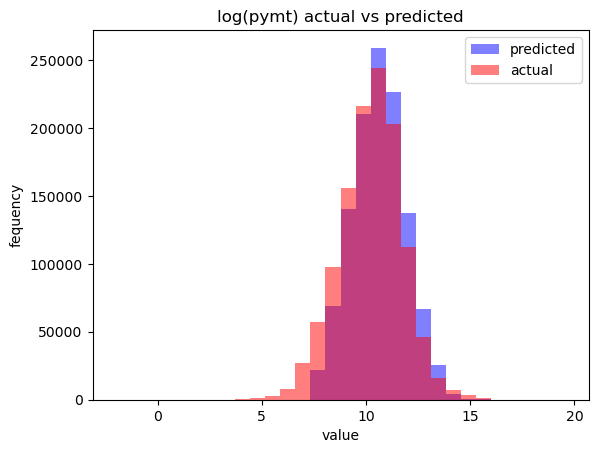

                 Generalized Linear Model Regression Results                  
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880931
Model Family:                   Gamma   Df Model:                           12
Link Function:                    Log   Scale:                          62.938
Method:                          IRLS   Log-Likelihood:            -1.0046e+08
Date:                Mon, 09 Mar 2026   Deviance:                   6.5616e+06
Time:                        12:59:13   Pearson chi2:                 4.33e+08
No. Iterations:                    17   Pseudo R-squ. (CS):           0.004371
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [ ]:
formula = best_formula(RESULT_DF,'abs_val_percentage')

MODEL_2 = smf.glm(
                formula = formula,
                data = X_train,
                family = sm.families.Gamma(link=sm.families.links.Log()),
                offset = np.log(X_train['Tot_Benes'])
            ).fit()

y_pred = MODEL_2.predict(X_val,offset=np.log(X_val['Tot_Benes'].apply(lambda x:x if x!=0 else 1)))

print(sum(y_pred)/actual_total_y)

log_y_pred = np.log(y_pred.apply(lambda x:x if x!=0 else 1))
log_actual_y = np.log(actual_y.apply(lambda x:x if x!=0 else 1))

bins = np.histogram_bin_edges(np.concatenate([log_y_pred, log_actual_y]), bins=30)

plt.hist(log_y_pred, bins=bins, alpha=0.5, color="blue", label="predicted")
plt.hist(log_actual_y, bins=bins, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted')
plt.show()

print(MODEL_2.summary())